<a href="https://colab.research.google.com/github/allnlk/ML/blob/main/%D0%9B%D0%A0_2_2_%D0%9A%D1%83%D0%B1%D1%80%D0%B0%D0%BA_3_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as plt

In [2]:
import kagglehub
import os

path = kagglehub.dataset_download("mahmoudshogaa/titanic-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


In [3]:
df = pd.read_csv(os.path.join(path, "titanic.csv"))

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


**PassengerId:** Унікальний ідентифікатор для кожного пасажира.

**Survived:** У цьому стовпці вказується, чи вижив пасажир (1), чи ні (0).

**Pclass:** (Клас квитка): Показник соціально-економічного статусу, де 1 – найвищий клас, а 3 – найнижчий.

**Name:** Ім'я пасажира.

**Sex:** Стать пасажира.

**Age:** Вік пасажира. (Примітка: У цьому стовпці можуть бути відсутні значення.)

**SibSp:** Кількість братів і сестер або подружжя пасажира на борту «Титаніка».

**Parch:** Кількість батьків або дітей пасажира на борту «Титаніка».

**Ticket:** Номер квитка.

**Fare:** Сума грошей, яку пасажир сплатив за квиток.





2. Визначити розмір датасета.
3. Визначити тип даних.

In [8]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


(891, 12)

In [6]:
df.duplicated().sum()

np.int64(0)

4. Визначити наявність пропущених значень. При наявності, замінити пропущені значення на середнє значення.

In [9]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [34]:
df.loc[:, 'Age'] = df['Age'].fillna(df['Age'].median())



5. Ще раз перевірити наявність пропущених значень.

In [35]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
Fare,0
Face_Category,0
Fare_Category,0


6. Сформувати датасет з обраними стовпцями: ['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

In [36]:
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500


7. Замінити бінарні ознаки (Стать) на 0 і 1 (але перевірте унікальні значення даного стовпчика). Буває, що є середня стать)

In [13]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


In [15]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

print(f'Data types of the datasets:\n{df.dtypes}')

Data types of the datasets:
Survived      int64
Pclass        int64
Sex           int64
Age         float64
Fare        float64
dtype: object


/tmp/ipykernel_1048/1657932846.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})


8. Вивести описову статистику датасету describe()

In [16]:
df.describe()

,Survived,Pclass,Sex,Age,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000
mean,0.383838,2.308642,0.352413,29.699118,32.204208
std,0.486592,0.836071,0.477990,14.526497,49.693429
min,0.000000,1.000000,0.000000,0.420000,0.000000
25%,0.000000,2.000000,0.000000,20.125000,7.910400
50%,0.000000,3.000000,0.000000,28.000000,14.454200
75%,1.000000,3.000000,1.000000,38.000000,31.000000
max,1.000000,3.000000,1.000000,80.000000,512.329200


9. Ще раз перевірити кількість пропущених даних (впевнитись, що їх немає).

In [37]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
Fare,0


10. Вивести 5 перших рядків датасету.

In [38]:
df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500


11. Вивести 5 останніх рядків датасету.

In [39]:
df.tail()

,Survived,Pclass,Sex,Age,Fare
886,0,2,0,27.0,13.00
887,1,1,1,19.0,30.00
888,0,3,1,28.0,23.45
889,1,1,0,26.0,30.00
890,0,3,0,32.0,7.75


12. Аналіз виживання залежно від статі: Обчисліть відсоток виживання для кожної статі. Чи була різниця у виживанні між чоловіками та жінками?

In [40]:
survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100

print(f'Share of survived males: {survival_by_sex[0]:.2f}%')
print(f'Share of survived females: {survival_by_sex[1]:.2f}%')

Share of survived males: 18.89%
Share of survived females: 74.20%


In [41]:
print(f'Correlation between sex and survival: {df['Sex'].corr(df['Survived'])}')

Correlation between sex and survival: 0.5433513806577555


Так, значна різниця. Жінки виживали значно частіше за чоловіків — відсоток виживання серед жінок склав 74.20%, у той час як серед чоловіків — лише 18.89%.

13. Обчисліть відсоток виживання для кожного класу (Pclass). Який клас мав найвищий рівень виживання (дати відповідь)?

In [42]:
survival_by_class = df.groupby('Pclass')['Survived'].mean() * 100

for pclass, rate in survival_by_class.items():
    print(f"Відсоток виживання {pclass}-го класу: {rate:.2f}%")

best_class = survival_by_class.idxmax()
print(f"\nВідповідь: Найвищий рівень виживання мав {best_class}-й клас.")


Відсоток виживання 1-го класу: 62.96%
Відсоток виживання 2-го класу: 47.28%
Відсоток виживання 3-го класу: 24.24%

Відповідь: Найвищий рівень виживання мав 1-й клас.


Найвищий рівень виживання мав 1-й клас.
Існує пряма залежність між класом каюти та шансами на порятунок: чим вищий клас, тим вищим був відсоток виживших.

14. Визначте середній вік тих, хто вижив, і тих, хто не вижив. Чи впливає вік на виживання (дати відповідь)?

In [44]:
mean_age = df.groupby('Survived')['Age'].mean()

print(f"Mean age of survived passengers: {mean_age[1]:.2f}")
print(f"Mean age of not survived passengers: {mean_age[0]:.2f}")


Mean age of survived passengers: 28.29
Mean age of not survived passengers: 30.03


Вік мав помітний вплив на виживання, оскільки в першу чергу намагалися рятувати дітей та молодь (серед дітей до 10 років рівень виживання був найвищим), що й знизило середній вік виживших пасажирів.

15. Розподіліть пасажирів на групи за рівнями тарифів (Fare) і обчисліть рівень виживання для кожної групи. Як тариф впливав на шанси виживання (дати відповідь)?

In [46]:
df.loc[:, 'Fare_Category'] = pd.qcut(df['Fare'], 6, labels=False)

surv_by_fare = df.groupby('Fare_Category')['Survived'].mean() * 100

for bucket, surv_rate in surv_by_fare.items():
    print(f'Share of survived passengers in bucket {bucket}: {surv_rate:.2f}%')


Share of survived passengers in bucket 0: 20.51%
Share of survived passengers in bucket 1: 19.08%
Share of survived passengers in bucket 2: 36.69%
Share of survived passengers in bucket 3: 43.62%
Share of survived passengers in bucket 4: 41.78%
Share of survived passengers in bucket 5: 69.80%


/tmp/ipykernel_1048/1542460063.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'Fare_Category'] = pd.qcut(df['Fare'], 6, labels=False)


Так, тариф напряму впливав на виживання  чим дорожчий квиток, тим вищі шанси вижити:
пасажири з дорожчими квитками мали каюти ближче до  палуби, тому швидше дісталися до рятувальних шлюпок.

16. Аналіз класу та тарифу: Визначте середній тариф (Fare) для кожного класу (Pclass). Чи існує значна різниця у тарифах між класами (дати відповідь)?

In [48]:
df.loc[:, 'Fare_Category'] = pd.qcut(df['Fare'], 6, labels=False)

surv_by_fare = df.groupby('Fare_Category')['Survived'].mean() * 100

for bucket, surv_rate in surv_by_fare.items():
    print(f'Share of survived passengers in bucket {bucket}: {surv_rate:.2f}%')


Share of survived passengers in bucket 0: 20.51%
Share of survived passengers in bucket 1: 19.08%
Share of survived passengers in bucket 2: 36.69%
Share of survived passengers in bucket 3: 43.62%
Share of survived passengers in bucket 4: 41.78%
Share of survived passengers in bucket 5: 69.80%


Так, різниця значна. Квитки 1-го класу були в середньому більш ніж у 4 рази дорожчими за 2-й клас і в 6 разів дорожчими за 3-й клас.

17. Як пов'язано середній вік пасажирів з виживанням? Відповідь дати аналітично чи графічно

<Axes: xlabel='Age', ylabel='Count'>

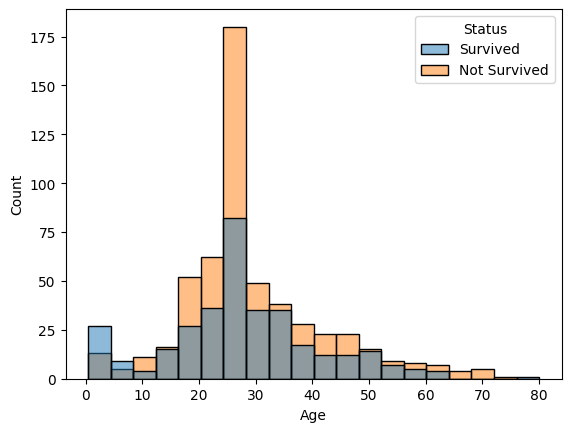

In [49]:
df_survived = df[df['Survived'] == 1][['Age']]
df_survived['Status'] = 'Survived'

df_not_survived = df[df['Survived'] == 0][['Age']]
df_not_survived['Status'] = 'Not Survived'

df_combined = pd.concat([df_survived, df_not_survived])

sns.histplot(data=df_combined, x='Age', hue='Status', bins=20)

Так, зв'язок між віком і виживанням помітно з графіку:

Діти (до 10 років): мали найвищий відсоток виживання, оскільки їх рятували в першу чергу.

Молодь (20–30 років): склала найбільшу частку загиблих (найвищий пік на графіку).

Старші люди: мали найнижчі шанси на порятунок.

In [31]:
# Clalculate survival rate per class per sex

# Розрахунок відсотка виживання для кожного класу та статі
for i in range(1, 4):
    for j in range(2):
        gender = "male" if j == 0 else "female"
        surv_rate = df[(df['Pclass'] == i) & (df['Sex'] == j) & (df['Survived'] == 1)].shape[0] / df[(df['Pclass'] == i) & (df['Sex'] == j)].shape[0]
        print(f'Share of survived {gender} passengers in class {i}: {surv_rate * 100:.2f}%')

Share of survived male passengers in class 1: 36.89%
Share of survived female passengers in class 1: 96.81%
Share of survived male passengers in class 2: 15.74%
Share of survived female passengers in class 2: 92.11%
Share of survived male passengers in class 3: 13.54%
Share of survived female passengers in class 3: 50.00%


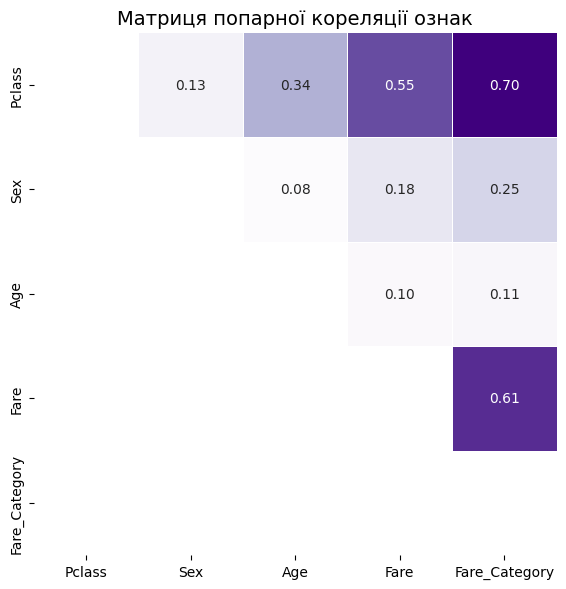

In [57]:
mtx = df.drop('Survived', axis=1).corr(numeric_only=True).abs()
fig, ax = plt.subplots(figsize=(6, 6))

sns.heatmap(
    mtx,
    cmap='Purples',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar=False,
    mask=np.tril(
        np.ones_like(mtx, dtype=bool)
    ),
    square=True,
    ax=ax,
)

plt.title('Матриця попарної кореляції ознак', fontsize=14)
plt.tight_layout()
plt.show()

Найсильніший зв'язок спостерігається між вартістю квитка (Fare) та тарифною групою (Fare_Category) — кореляція 0.61. Також є помітна залежність між класом (Pclass) та вартістю квитка. Зв'язок між віком (Age) та іншими числовими параметрами слабкий (до 0.11).